<a href="https://colab.research.google.com/github/Rishitha110506/Machine-Learning/blob/main/ML_Lab_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MACHINE LEARNING ASSIGNMENT 06

NAME : KAMPALLI RISHITHA


REG NO : BL.SC.U4AIE24020

SEC : D.Sec

loading and fetching data

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving BERT_Embeddings.xlsx to BERT_Embeddings.xlsx


In [ ]:
import pandas as pd

# Load your Excel data (replace 'your_file.xlsx' with actual filename)
df = pd.read_excel('BERT_Embeddings.xlsx')  # or pd.read_csv('your_file.csv')

# Verify data loaded correctly
print("Data shape:", df.shape)
print(df.head())  # Shows first 5 rows

Data shape: (3311, 771)
          0         1         2         3         4         5         6  \
0  0.025568  0.042430  0.016463  0.205958  0.072169  0.122228 -0.003409   
1  0.205218 -0.000216  0.329248 -0.133093 -0.023144  0.092500 -0.183787   
2  0.302459  0.087675  0.266277  0.174928  0.270119 -0.122046  0.085451   
3  0.283325  0.167030  0.139336  0.094306 -0.020424  0.093841 -0.021465   
4  0.320879 -0.093648  0.119425  0.191417 -0.007830  0.236620 -0.052938   

          7         8         9  ...       761       762       763       764  \
0  0.024455  0.047286  0.127876  ...  0.171996 -0.279748  0.083019  0.000174   
1 -0.151052 -0.051019 -0.275225  ... -0.107421 -0.224334 -0.263269  0.224133   
2  0.049851  0.001328 -0.030801  ... -0.026183 -0.267059  0.190339  0.153742   
3 -0.105555 -0.249112  0.081326  ... -0.166081 -0.045050  0.052088  0.248291   
4  0.227950 -0.005876 -0.028800  ... -0.328193 -0.448884  0.220072  0.114238   

        765       766       767  \
0  0.1722

(A1) The code takes the chosen target column from our dataset, splits its continuous values into four equal‑width ranges (bins), and assigns each value to a bin. It then counts how many values fall into each bin, converts those counts into probabilities, and applies the entropy formula. Finally, it prints the bin edges, the probability distribution across bins, and the entropy value, which reflects how evenly or unevenly the data is spread across those bins.

In [ ]:
import numpy as np
import pandas as pd

def equal_width_binning(y, n_bins=4):
    y = np.array(y)
    bins = np.linspace(y.min(), y.max(), n_bins + 1)
    labels = np.digitize(y, bins, right=False) - 1
    return labels, bins

def calculate_entropy(labels):
    values, counts = np.unique(labels, return_counts=True)
    probabilities = counts / counts.sum()
    entropy = -np.sum(probabilities * np.log2(probabilities))
    return entropy, probabilities


# Use already-loaded dataset
target_col_index = df.shape[1] - 1
y = df.iloc[:, target_col_index].values

# Apply binning
labels, bins = equal_width_binning(y, n_bins=4)

# Calculate entropy
entropy_value, probabilities = calculate_entropy(labels)

# Print results
print("Bin edges:", bins)
print("Probabilities per bin:", probabilities)
print(f"Entropy of the dataset (with 4 bins): {entropy_value:.4f}")


Bin edges: [1.  1.5 2.  2.5 3. ]
Probabilities per bin: [0.13651465 0.34158864 0.52189671]
Entropy of the dataset (with 4 bins): 1.4112


(A2) The Gini index code works by splitting the target column’s continuous values into four equal‑width bins, assigning each value to a bin, and then calculating the probability of values in each bin. It applies the formula
which measures impurity in the distribution. The output shows the bin edges, the probabilities per bin, and the final Gini index value that reflects how mixed the data is across those bins.

In [ ]:
import numpy as np
import pandas as pd

def equal_width_binning(y, n_bins=4):

    y = np.array(y)
    bins = np.linspace(y.min(), y.max(), n_bins + 1)
    labels = np.digitize(y, bins, right=False) - 1
    return labels, bins

def calculate_gini(labels):

    values, counts = np.unique(labels, return_counts=True)
    probabilities = counts / counts.sum()
    gini = 1 - np.sum(probabilities ** 2)
    return gini, probabilities



# Using already-loaded dataset
target_col_index = df.shape[1] - 1   # change this to match your actual label column
y = df.iloc[:, target_col_index].values

# Step 1: Bin the target values
labels, bins = equal_width_binning(y, n_bins=4)

# Step 2: Calculate Gini index
gini_value, probabilities = calculate_gini(labels)

# Step 3: Print results
print("Bin edges:", bins)
print("Probabilities per bin:", probabilities)
print(f"Gini Index of the dataset (with 4 bins): {gini_value:.4f}")

Bin edges: [1.  1.5 2.  2.5 3. ]
Probabilities per bin: [0.13651465 0.34158864 0.52189671]
Gini Index of the dataset (with 4 bins): 0.5923


(A3)

In [ ]:
import numpy as np
import pandas as pd

def calculate_entropy(labels):
    values, counts = np.unique(labels, return_counts=True)
    probabilities = counts / counts.sum()
    entropy = -np.sum(probabilities * np.log2(probabilities))
    return entropy

def information_gain(df, feature, target):
    total_entropy = calculate_entropy(df[target])
    values, counts = np.unique(df[feature], return_counts=True)

    weighted_entropy = 0
    for v, c in zip(values, counts):
        subset = df[df[feature] == v][target]
        weighted_entropy += (c / len(df)) * calculate_entropy(subset)

    return total_entropy - weighted_entropy

def preprocess_features(df, target):
    """Convert all features to categorical (bin numeric ones)."""
    for col in df.columns:
        if col != target:
            if np.issubdtype(df[col].dtype, np.number):
                # Bin numeric features into 4 categories
                df[col] = pd.cut(df[col], bins=4, labels=False)
            else:
                # Convert non-numeric features to string categories
                df[col] = df[col].astype(str)
    return df

def find_root_node(df, target='label'):
    df = preprocess_features(df.copy(), target)
    features = [col for col in df.columns if col != target]
    gains = {feature: information_gain(df, feature, target) for feature in features}
    root_feature = max(gains, key=gains.get)
    return root_feature, gains

# === Run on your dataset ===
root, gain_scores = find_root_node(df, target='label')

print("Root feature:", root)
print("Information Gains:", gain_scores)

Root feature: Student
Information Gains: {0: np.float64(0.0035253831368307065), 1: np.float64(0.004458002047776022), 2: np.float64(0.00465897620257083), 3: np.float64(0.0022442262838884286), 4: np.float64(0.012365431100068713), 5: np.float64(0.0032371924765386417), 6: np.float64(0.007247696549829374), 7: np.float64(0.007948414754743505), 8: np.float64(0.0041214040682280295), 9: np.float64(0.008912091929829336), 10: np.float64(0.002478528254376222), 11: np.float64(0.006759390113585617), 12: np.float64(0.00664362260127338), 13: np.float64(0.012219361535301454), 14: np.float64(0.007302721582292282), 15: np.float64(0.02144618495246453), 16: np.float64(0.0041723319288724525), 17: np.float64(0.002951799348062556), 18: np.float64(0.018200827870218816), 19: np.float64(0.00881061911996972), 20: np.float64(0.003680271040389149), 21: np.float64(0.008653153815226355), 22: np.float64(0.002993488749365225), 23: np.float64(0.003155516278463555), 24: np.float64(0.007776190033911057), 25: np.float64(0.

(A4) code defines a binning function and then applies it to every numeric column in the DataFrame. For each column, it creates a new version with values grouped into 4 equal‑width bins, stores these in a dictionary, and finally merges them back into the original DataFrame. In short, it automatically adds binned categorical versions of all numeric features alongside the original data.

In [13]:
from google.colab import files
uploaded = files.upload()

Saving BERT_Embeddings.xlsx to BERT_Embeddings.xlsx


In [14]:
import pandas as pd

df = pd.read_excel('BERT_Embeddings.xlsx')

print("Data shape:", df.shape)
print(df.head())
print(df.columns)

Data shape: (3311, 771)
          0         1         2         3         4         5         6  \
0  0.025568  0.042430  0.016463  0.205958  0.072169  0.122228 -0.003409   
1  0.205218 -0.000216  0.329248 -0.133093 -0.023144  0.092500 -0.183787   
2  0.302459  0.087675  0.266277  0.174928  0.270119 -0.122046  0.085451   
3  0.283325  0.167030  0.139336  0.094306 -0.020424  0.093841 -0.021465   
4  0.320879 -0.093648  0.119425  0.191417 -0.007830  0.236620 -0.052938   

          7         8         9  ...       761       762       763       764  \
0  0.024455  0.047286  0.127876  ...  0.171996 -0.279748  0.083019  0.000174   
1 -0.151052 -0.051019 -0.275225  ... -0.107421 -0.224334 -0.263269  0.224133   
2  0.049851  0.001328 -0.030801  ... -0.026183 -0.267059  0.190339  0.153742   
3 -0.105555 -0.249112  0.081326  ... -0.166081 -0.045050  0.052088  0.248291   
4  0.227950 -0.005876 -0.028800  ... -0.328193 -0.448884  0.220072  0.114238   

        765       766       767  \
0  0.1722

In [18]:
import pandas as pd

def bin_feature(series, bin_type='equal_width', num_bins=4):
    if bin_type == 'equal_width':
        return pd.cut(series, bins=num_bins, labels=False)
    elif bin_type == 'frequency':
        return pd.qcut(series, q=num_bins, labels=False, duplicates='drop')
    else:
        raise ValueError("bin_type must be 'equal_width' or 'frequency'")

binned_columns = {}


for col in df.select_dtypes(include='number').columns:
    binned_columns[f"{col}_binned"] = bin_feature(df[col], bin_type='equal_width', num_bins=4)


df = pd.concat([df, pd.DataFrame(binned_columns)], axis=1)

print(df.head())


          0         1         2         3         4         5         6  \
0  0.025568  0.042430  0.016463  0.205958  0.072169  0.122228 -0.003409   
1  0.205218 -0.000216  0.329248 -0.133093 -0.023144  0.092500 -0.183787   
2  0.302459  0.087675  0.266277  0.174928  0.270119 -0.122046  0.085451   
3  0.283325  0.167030  0.139336  0.094306 -0.020424  0.093841 -0.021465   
4  0.320879 -0.093648  0.119425  0.191417 -0.007830  0.236620 -0.052938   

          7         8         9  ...  759_binned_binned  760_binned_binned  \
0  0.024455  0.047286  0.127876  ...                  2                  1   
1 -0.151052 -0.051019 -0.275225  ...                  1                  2   
2  0.049851  0.001328 -0.030801  ...                  2                  3   
3 -0.105555 -0.249112  0.081326  ...                  1                  2   
4  0.227950 -0.005876 -0.028800  ...                  1                  1   

   761_binned_binned  762_binned_binned  763_binned_binned  764_binned_binned  \

(A5) This code builds a custom Decision Tree. It preprocesses our data by reducing dimensions with PCA and then binning continuous features. It then uses entropy and information gain to recursively build a decision tree, which is subsequently used to make predictions.

In [37]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA


df = pd.read_excel('BERT_Embeddings.xlsx')

label_column = 'label'


embedding_cols = [col for col in df.columns if isinstance(col, (int, np.int64)) and col != label_column]


if not embedding_cols:
    raise ValueError("No numeric embedding columns found for PCA. Please check your DataFrame structure.")


pca = PCA(n_components=5)
reduced_features = pca.fit_transform(df[embedding_cols])


reduced_df = pd.DataFrame(reduced_features, columns=[f"pc{i+1}" for i in range(5)])


reduced_df[label_column] = df[label_column]


def bin_feature(series, bin_type='equal_width', num_bins=4):
    if bin_type == 'equal_width':
        return pd.cut(series, bins=num_bins, labels=False, include_lowest=True)
    elif bin_type == 'frequency':
        return pd.qcut(series, q=num_bins, labels=False, duplicates='drop', include_lowest=True)
    else:
        raise ValueError("bin_type must be 'equal_width' or 'frequency'")

binned_columns = {}
for col in reduced_df.select_dtypes(include=np.number).columns:
    if col != label_column:
        binned_columns[f"{col}_binned"] = bin_feature(reduced_df[col], bin_type='equal_width', num_bins=4)

df_binned = pd.concat([reduced_df, pd.DataFrame(binned_columns)], axis=1)


def calculate_entropy(y):
    values, counts = np.unique(y, return_counts=True)
    probabilities = counts / counts.sum()
    probabilities = probabilities[probabilities > 0]
    entropy = -np.sum(probabilities * np.log2(probabilities))
    return entropy


def information_gain(y, x):
    total_entropy = calculate_entropy(y)
    values, counts = np.unique(x, return_counts=True)

    weighted_entropy = 0
    for v, c in zip(values, counts):
        subset_y = y[x == v]
        if len(subset_y) > 0:
            weighted_entropy += (c / len(x)) * calculate_entropy(subset_y)

    return total_entropy - weighted_entropy


def build_tree(X, y, features):

    if len(np.unique(y)) == 1:
        return {'label': y.iloc[0]}

    if len(features) == 0:
        return {'label': y.mode()[0]}
    if len(features) == 0:
        return {'label': y.mode()[0]}


    gains = [information_gain(y, X[feature]) for feature in features]

    best_feature_index = np.argmax(gains)
    best_feature = features[best_feature_index]

    tree = {'feature': best_feature, 'branches': {}}

    for value in np.unique(X[best_feature]):
        sub_X = X[X[best_feature] == value]
        sub_y = y[X[best_feature] == value]

        if len(sub_y) == 0:
            tree['branches'][value] = {'label': y.mode()[0]}
        else:
            remaining_features = [f for f in features if f != best_feature]
            subtree = build_tree(sub_X, sub_y, remaining_features)
            tree['branches'][value] = subtree

    return tree


def predict(tree, sample):
    while 'label' not in tree:
        feature_to_split = tree['feature']
        feature_value = sample.get(feature_to_split)

        if feature_value in tree['branches']:
            tree = tree['branches'][feature_value]
        else:
            print(f"Warning: Value {feature_value} for feature {feature_to_split} not found in branches.")
            return None

    return tree['label']



features_for_tree = [col for col in df_binned.columns if col.startswith('pc') and col.endswith('_binned')]

X_train = df_binned[features_for_tree]
y_train = df_binned[label_column]

print("Building Decision Tree...")
decision_tree = build_tree(X_train, y_train, features_for_tree)
print("Decision Tree built successfully.")

sample_to_predict = X_train.iloc[0].to_dict()

predicted_label = predict(decision_tree, sample_to_predict)

print(f"\nPrediction for the first sample (binned features: {sample_to_predict}): {predicted_label}")
print(f"Actual label for the first sample: {y_train.iloc[0]}")

Building Decision Tree...
Decision Tree built successfully.

Prediction for the first sample (binned features: {'pc1_binned': 0, 'pc2_binned': 2, 'pc3_binned': 2, 'pc4_binned': 1, 'pc5_binned': 1}): 3
Actual label for the first sample: 3


### A6. Visualize the Decision Tree (without direct image output)

In [42]:
import sys
!{sys.executable} -m pip install graphviz
print("Graphviz installation check complete.")

Graphviz installation check complete.


This code will generate a graphical representation of your `decision_tree` and save it as `decision_tree.png` in your Colab environment. You can then download and view this file. The output in the notebook will confirm the file creation without displaying the image directly.

In [43]:
from graphviz import Digraph
import numpy as np

def convert_np_int64_keys_to_int(obj):
    """Recursively converts numpy.int64 keys in dictionaries to standard Python int."""
    if isinstance(obj, dict):
        return {convert_np_int64_keys_to_int(k): convert_np_int64_keys_to_int(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_np_int64_keys_to_int(elem) for elem in obj]
    elif isinstance(obj, np.int64):
        return int(obj)
    else:
        return obj

def plot_tree_recursive(node, parent_name, dot, node_id_counter):
    current_node_id = f"node_{next(node_id_counter)}"

    if 'label' in node:
        # Leaf node
        label_text = f"Label: {node['label']}"
        dot.node(name=current_node_id, label=label_text, shape='box', style='filled', fillcolor='lightgreen')
    else:
        # Internal node
        feature = node['feature']
        label_text = f"Feature: {feature}"
        dot.node(name=current_node_id, label=label_text, shape='ellipse', style='filled', fillcolor='lightblue')

        for value, branch in node['branches'].items():
            child_node_id = plot_tree_recursive(branch, current_node_id, dot, node_id_counter)
            # Add edge from current_node_id to child_node_id with the value as label
            dot.edge(current_node_id, child_node_id, label=str(value))
    return current_node_id

# Convert np.int64 keys/values in the decision_tree dictionary to standard Python int
printable_decision_tree = convert_np_int64_keys_to_int(decision_tree)

# Create a Digraph object
dot = Digraph(comment='DecisionTree', format='png', graph_attr={'rankdir': 'TB'})

# Use a generator for unique node IDs
def node_id_generator():
    i = 0
    while True:
        yield i
        i += 1
node_id_counter = node_id_generator()

# Build the graph starting from the root of the converted tree
root_id = plot_tree_recursive(printable_decision_tree, 'Root', dot, node_id_counter)

# Render and save the tree to a file
dot.render('decision_tree', view=False, cleanup=True) # Saves to 'decision_tree.png'
print("Decision tree visualization saved as 'decision_tree.png'")
# Removed: dot # This line would display the graph directly

Decision tree visualization saved as 'decision_tree.png'


(A6) In this step, the goal is to represent the structure of the decision tree that was built using entropy and information gain.

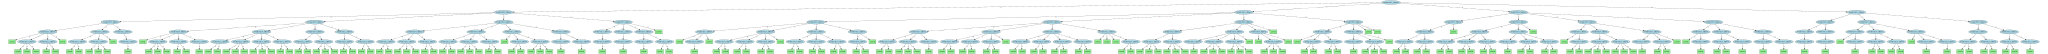

In [50]:
from graphviz import Digraph
import numpy as np
from IPython.display import display

def convert_np_int64_keys_to_int(obj):
    if isinstance(obj, dict):
        return {convert_np_int64_keys_to_int(k): convert_np_int64_keys_to_int(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_np_int64_keys_to_int(elem) for elem in obj]
    elif isinstance(obj, np.int64):
        return int(obj)
    else:
        return obj

def plot_tree_inline(node, parent_name, dot, node_id_counter):
    current_node_id = f"node_{next(node_id_counter)}"

    if 'label' in node:
        label_text = f"Label: {node['label']}"
        dot.node(name=current_node_id, label=label_text, shape='box', style='filled', fillcolor='lightgreen')
    else:
        feature = node['feature']
        label_text = f"Feature: {feature}"
        dot.node(name=current_node_id, label=label_text, shape='ellipse', style='filled', fillcolor='lightblue')

        for value, branch in node['branches'].items():
            child_node_id = plot_tree_inline(branch, current_node_id, dot, node_id_counter)
            dot.edge(current_node_id, child_node_id, label=str(value))
    return current_node_id

def node_id_generator():
    i = 0
    while True:
        yield i
        i += 1

# Prepare and display the tree
printable_tree = convert_np_int64_keys_to_int(decision_tree)
dot = Digraph(comment='DecisionTree', format='svg', graph_attr={'rankdir': 'TB'})
node_id_counter = node_id_generator()
plot_tree_inline(printable_tree, 'Root', dot, node_id_counter)
display(dot)


(A7) Here, the focus shifts from the tree structure to its decision boundaries in feature space. By selecting two binned features and plotting them on a 2D plane, we can use the trained tree to predict labels across a grid of values. The resulting contour plot shows regions where the tree assigns different classes, with the actual data points overlaid. This visualization helps to understand how the tree partitions the feature space and highlights the separations between classes.

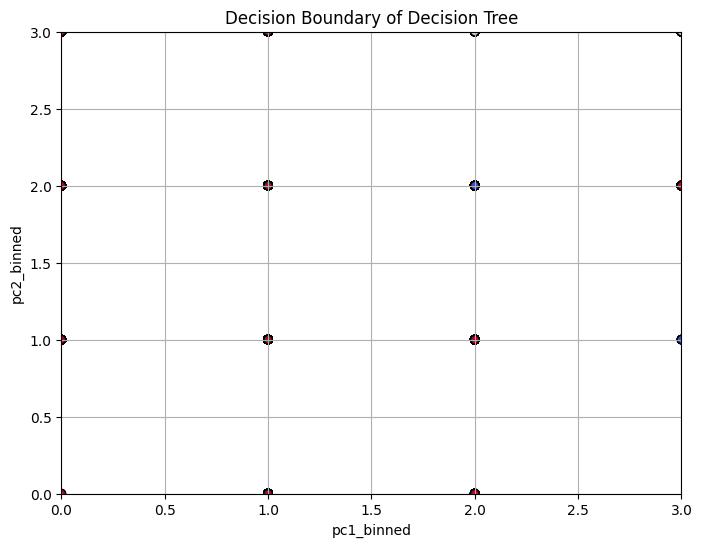

In [51]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Pick two binned features for visualization
feature1 = features_for_tree[0]
feature2 = features_for_tree[1]

X_vis = df_binned[[feature1, feature2]]
y_vis = df_binned[label_column]

# Create a meshgrid for plotting
x_min, x_max = X_vis[feature1].min(), X_vis[feature1].max()
y_min, y_max = X_vis[feature2].min(), X_vis[feature2].max()
xx, yy = np.meshgrid(np.arange(x_min, x_max + 1, 1),
                     np.arange(y_min, y_max + 1, 1))

# Predict over the grid
grid_points = pd.DataFrame({feature1: xx.ravel(), feature2: yy.ravel()})
preds = [predict(decision_tree, row.to_dict()) for _, row in grid_points.iterrows()]
Z = np.array(preds).reshape(xx.shape).astype(float)   # ensure numeric for contourf

# Plot decision boundary
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')
plt.scatter(X_vis[feature1], X_vis[feature2], c=y_vis.astype(float), edgecolors='k', cmap='coolwarm')
plt.xlabel(feature1)
plt.ylabel(feature2)
plt.title("Decision Boundary of Decision Tree")
plt.grid(True)
plt.show()
